Proyecto Final — Advanced Machine Learning (Deep Learning)


---

| Campo | Información |
|-------|-------------|
| **Estudiante** | Keyla Vargas |
| **Repositorio** | `DL-Final-Vargas-Keyla` |
| **Título** | Detección de Fraude en Transacciones Financieras Móviles con Deep Learning |
| **Profesor** | Carlos Mariño, Ph.D. |
| **Fecha** | 04/05/2026 |

---

## 📑 Índice
1. [Resumen Ejecutivo](#1)
2. [Configuración del Entorno](#2)
3. [Definición del Problema de Negocio](#3)
4. [Carga y Exploración de Datos — EDA](#4)
5. [Preprocesamiento — ML Pipeline](#5)
6. [Diseño y Arquitectura del Modelo MLP](#6)
7. [Entrenamiento del Modelo](#7)
8. [Evaluación y Métricas](#8)
9. [Interpretación de Resultados — SHAP](#9)
10. [Conclusiones y Recomendaciones de Negocio](#10)
11. [Referencias](#11)

---
<a id='1'></a>
## 1. Resumen Ejecutivo

---

Este proyecto aplica **Deep Learning** sobre el dataset **PaySim** para detectar fraude en transacciones financieras móviles. Se implementa una **Red Neuronal Multicapa (MLP)** usando **PyTorch** — framework de bajo nivel que ofrece control completo sobre cálculos y optimizaciones (Sesión 3-4).

**¿Por qué usamos PyTorch y no Keras?**
- Keras es una API de alto nivel ideal para prototipado rápido
- PyTorch ofrece control matemático completo sobre el training loop, gradientes y optimización
- Para un proyecto de investigación y aprendizaje profundo, PyTorch permite mayor comprensión del proceso

**Retos del dataset en cuestión:**
- Low signal-to-noise ratio: solo 0.13% de transacciones son fraude
- Data imbalance severo: ratio 770:1
- Data shifts: patrones de fraude evolucionan

**Técnicas aplicadas para evitar Overfitting:**
- Dropout, BatchNormalization, L2 Regularization, Early Stopping

**Resultado esperado:** AUC-ROC > 0.95, Recall > 80%

---

---
<a id='2'></a>
## 2. Configuración del Entorno

### 2.1 Verificación de GPU
> 💡 En Colab: **Runtime → Change runtime type → GPU**
> Los modelos de Deep Learning requieren hardware especializado (GPU/TPU) para entrenamiento eficiente

In [53]:
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"Memoria: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("GPU no disponible — usando CPU")
    print("   Tip: Runtime > Change runtime type > GPU")

print(f"\n Dispositivo activo: {device}")

GPU disponible: Tesla T4
Memoria: 15.6 GB

 Dispositivo activo: cuda


### 2.2 Instalación de Librerías

In [54]:
!pip install shap --quiet

### 2.3 Importación de Librerías

> **PyTorch** (framework bajo nivel — Sesión 3-4) vs **Keras** (API alto nivel):
> Usamos PyTorch para control completo del training loop y backpropagation

In [55]:
# ── Datos ──
import numpy as np
import pandas as pd

# ── Visualización ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Deep Learning — PyTorch (framework bajo nivel) ──
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── ML Pipeline — Sklearn ──
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ── Utilidades ──
import warnings, joblib, time
warnings.filterwarnings('ignore')

# ── Reproducibilidad ──
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Librerías importadas correctamente")
print(f"   PyTorch:  {torch.__version__}")
print(f"   NumPy:    {np.__version__}")
print(f"   Pandas:   {pd.__version__}")

Librerías importadas correctamente
   PyTorch:  2.10.0+cu128
   NumPy:    2.0.2
   Pandas:   2.2.2


### 2.4 Carga del Dataset desde Google Drive

In [56]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/DL_Final/'
CSV_FILE  = 'PS_20174392719_1491204439457_log.csv'

print(f"✅ Google Drive montado")
print(f"   Dataset esperado en: {BASE_PATH + CSV_FILE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado
   Dataset esperado en: /content/drive/MyDrive/DL_Final/PS_20174392719_1491204439457_log.csv


---
<a id='3'></a>
## 3. Definición del Problema de Negocio

### 3.1 Contexto AI → ML → DL

| **DL** | Extrae patrones usando redes neuronales multicapa | MLP con 3 capas ocultas sobre datos tabulares |

**Tipo de datos:** Estructurado / Tabular / Labeled Dataset
**Tarea:** Clasificación binaria supervisada (`isFraud` = 0 o 1)

---

### 3.2 Retos del Dataset

---

- **Low signal-to-noise ratio:** Solo 0.13% de transacciones son fraude
- **Data Imbalance:** 99.87% normal vs 0.13% fraude — sesgo hacia la clase mayoritaria
- **Data shifts:** Los patrones de fraude evolucionan continuamente
- **Irrelevant features:** IDs de cuentas no aportan señal al modelo

---

### 3.3 Objetivos

---

1. Ejecutar el **ML Pipeline completo** desde Data Retrieval hasta Model Evaluation
2. Aplicar **Feature Engineering** para capturar patrones de fraude
3. Implementar **MLP en PyTorch** con técnicas anti-overfitting (Dropout, L2, Early Stopping)
4. Comparar contra **modelos baseline** (Logistic Regression, Random Forest)
5. Interpretar el modelo con **SHAP** — abordando el Black Box Problem
6. Traducir resultados a **recomendaciones de negocio accionables**

---

---
<a id='4'></a>
## 4. Carga y Exploración de Datos — EDA

### 4.1 Data Retrieval

In [57]:
# Dataset ya subido directamente a Colab
import pandas as pd

df = pd.read_csv('/content/DL_FINAL/PS_20174392719_1491204439457_log.csv')

print(f"✅ Dataset PaySim cargado")
print(f"   Filas:    {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
print(f"   Memoria:  {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"   Tipo:     Structured / Labeled Dataset")
print(f"   Fuente:   Synthetic data — retiene estructura de datos reales")

✅ Dataset PaySim cargado
   Filas:    6,362,620
   Columnas: 11
   Memoria:  1523.1 MB
   Tipo:     Structured / Labeled Dataset
   Fuente:   Synthetic data — retiene estructura de datos reales


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 4.2 Descripción del Dataset

---

Dataset con Paysim porque son basados en datos reales de un operador de dinero móvil en África. Comolos datos sintéticos retienen la estructura estadística del original manteniendo privacidad.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `step` | Numérica | Hora de la transacción (1=1h, máx 744) |
| `type` | Categórica | CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER |
| `amount` | Numérica | Monto de la transacción |
| `oldbalanceOrg` | Numérica | Saldo previo — origen |
| `newbalanceOrig` | Numérica | Saldo posterior — origen |
| `oldbalanceDest` | Numérica | Saldo previo — destino |
| `newbalanceDest` | Numérica | Saldo posterior — destino |
| **`isFraud`** | **Binaria** | **TARGET: 1=fraude, 0=legítimo** |

---

In [29]:
print("=" * 60)
print("INSPECCIÓN INICIAL")
print("=" * 60)
display(df.head())
print("\n📈 Estadísticas descriptivas:")
display(df.describe())

INSPECCIÓN INICIAL


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0



📈 Estadísticas descriptivas:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.536598e+06,1.536598e+06,1.536598e+06,1.536598e+06,1.536598e+06,1.536598e+06,1.536597e+06,1536597.0
mean,6.132086e+01,1.610345e+05,8.700393e+05,8.908140e+05,9.891209e+05,1.114045e+06,1.138880e-03,0.0
std,5.220271e+01,2.695586e+05,2.959877e+06,2.996250e+06,2.302070e+06,2.406165e+06,3.372809e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.700000e+01,1.289010e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,3.900000e+01,7.750487e+04,1.532400e+04,0.000000e+00,1.322262e+05,2.225372e+05,0.000000e+00,0.0
75%,1.310000e+02,2.160513e+05,1.254459e+05,1.663345e+05,9.359249e+05,1.151265e+06,0.000000e+00,0.0
max,1.540000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.220740e+07,4.220740e+07,1.000000e+00,0.0


In [30]:
print("=" * 60)
print("DATA QUALITY CHECK (Sesión 1-2)")
print("=" * 60)

# Valores faltantes
missing = df.isnull().sum()
print(f"\n Valores faltantes: {missing.sum()}")
print(" Dataset completo" if missing.sum() == 0 else missing[missing>0])

# Duplicados
dupes = df.duplicated().sum()
print(f"\n🔍 Duplicados: {dupes}")
print("   ✅ Sin duplicados" if dupes == 0 else f"   ⚠️  {dupes} duplicados encontrados")

# Desbalance
class_dist = df['isFraud'].value_counts()
ratio = class_dist[0] / class_dist[1]
print(f"\nDATA IMBALANCE (Sesión 1-2):")
print(f"   Normal (0): {class_dist[0]:,} ({class_dist[0]/len(df)*100:.2f}%)")
print(f"   Fraude (1): {class_dist[1]:,} ({class_dist[1]/len(df)*100:.4f}%)")
print(f"   Ratio:      {ratio:.0f}:1 → usaremos pos_weight en la Loss Function")

DATA QUALITY CHECK (Sesión 1-2)

 Valores faltantes: 2
isFraud           1
isFlaggedFraud    1
dtype: int64

🔍 Duplicados: 0
   ✅ Sin duplicados

DATA IMBALANCE (Sesión 1-2):
   Normal (0): 1,534,847 (99.89%)
   Fraude (1): 1,750 (0.1139%)
   Ratio:      877:1 → usaremos pos_weight en la Loss Function


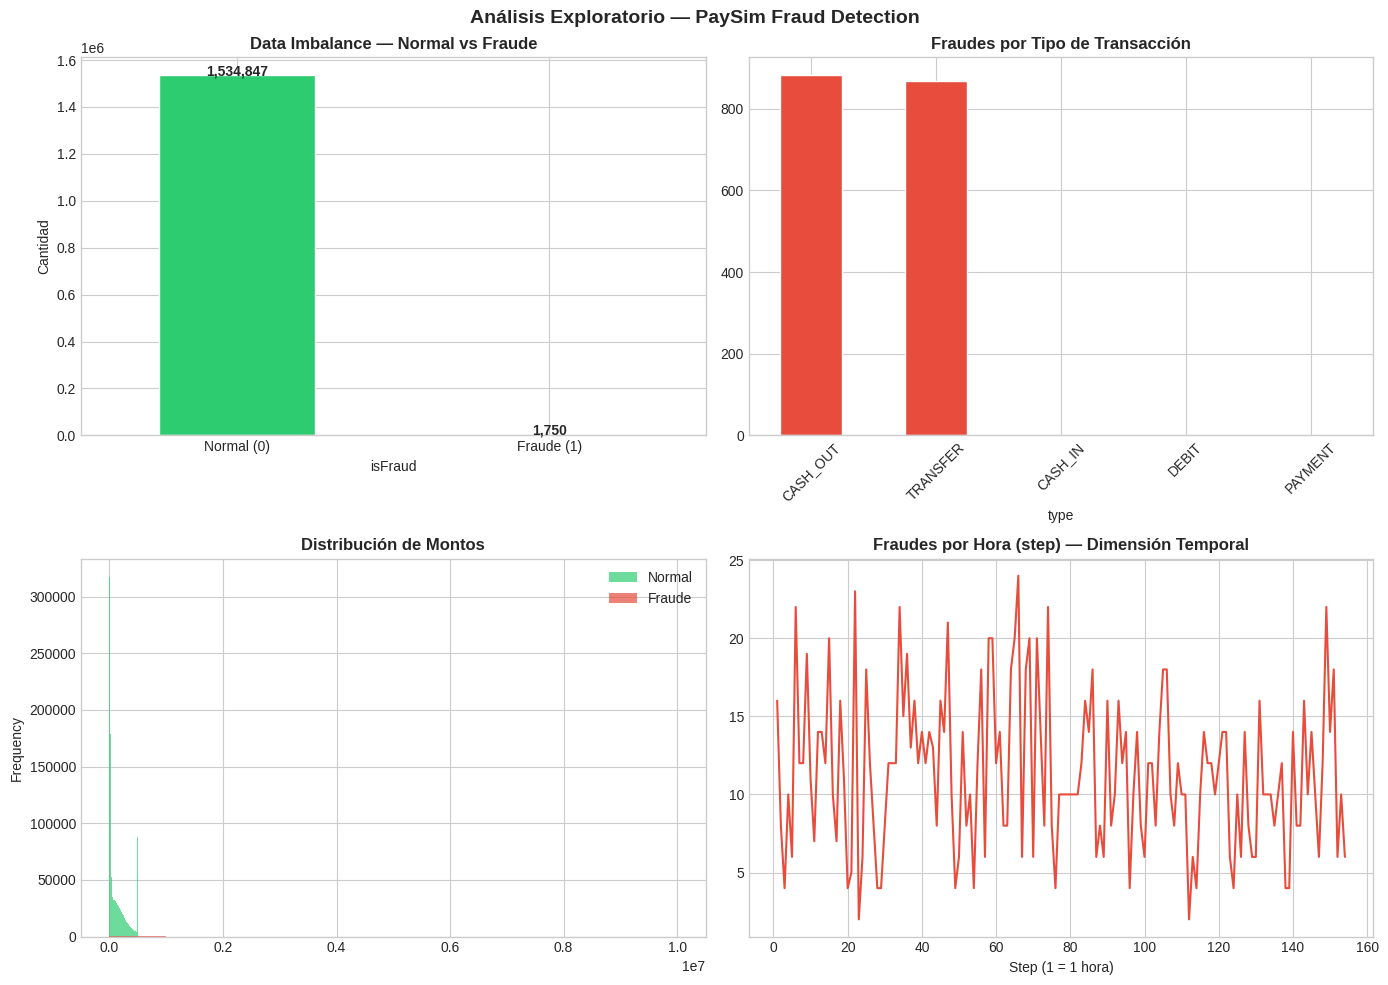


💡 KEY INSIGHT: Fraude SOLO ocurre en CASH_OUT y TRANSFER
   → El dataset tiene dimensión temporal (step) — base para modelos RNN/LSTM


In [31]:
# EDA Visual
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Exploratorio — PaySim Fraud Detection', fontsize=14, fontweight='bold')

# Plot 1: Distribución de clases
class_dist.plot(kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0,0].set_title('Data Imbalance — Normal vs Fraude', fontweight='bold')
axes[0,0].set_xticklabels(['Normal (0)', 'Fraude (1)'], rotation=0)
axes[0,0].set_ylabel('Cantidad')
for i, v in enumerate(class_dist.values):
    axes[0,0].text(i, v+1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Fraude por tipo
fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', ax=axes[0,1], color='#e74c3c', edgecolor='white')
axes[0,1].set_title('Fraudes por Tipo de Transacción', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Montos
df[df['isFraud']==0]['amount'].clip(upper=500000).plot(
    kind='hist', bins=50, ax=axes[1,0], color='#2ecc71', alpha=0.7, label='Normal')
df[df['isFraud']==1]['amount'].plot(
    kind='hist', bins=50, ax=axes[1,0], color='#e74c3c', alpha=0.7, label='Fraude')
axes[1,0].set_title('Distribución de Montos', fontweight='bold')
axes[1,0].legend()

# Plot 4: Fraude en el tiempo
df[df['isFraud']==1].groupby('step').size().plot(
    ax=axes[1,1], color='#e74c3c', lw=1.5)
axes[1,1].set_title('Fraudes por Hora (step) — Dimensión Temporal', fontweight='bold')
axes[1,1].set_xlabel('Step (1 = 1 hora)')

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT: Fraude SOLO ocurre en CASH_OUT y TRANSFER")
print("   → El dataset tiene dimensión temporal (step) — base para modelos RNN/LSTM")

MATRIZ DE CORRELACIONES


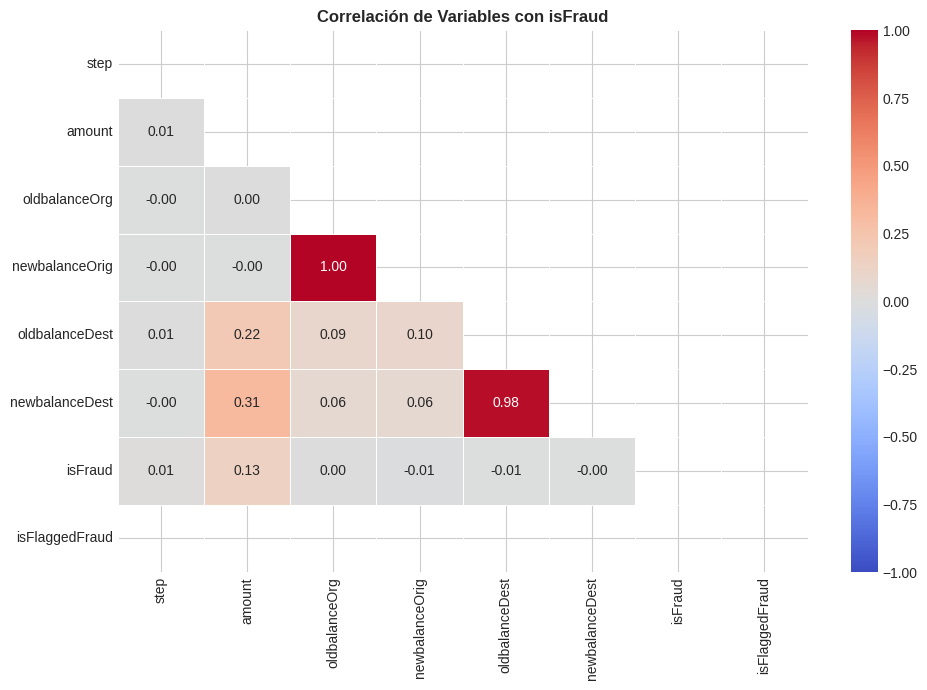


 Correlación con isFraud:
amount            0.134532
step              0.008830
oldbalanceOrg     0.004497
newbalanceDest   -0.000082
oldbalanceDest   -0.007590
newbalanceOrig   -0.009651
isFlaggedFraud         NaN
Name: isFraud, dtype: float64


In [32]:
# Correlaciones
print("=" * 60)
print("MATRIZ DE CORRELACIONES")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Correlación de Variables con isFraud', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Correlación con isFraud:")
print(corr_matrix['isFraud'].drop('isFraud').sort_values(ascending=False))

---
<a id='5'></a>
## 5. Preprocesamiento — ML Pipeline

> **ML Pipeline:** Data Processing → Feature Engineering → Feature Scaling → Feature Selection

### 5.1 Data Processing & Wrangling

In [33]:
print("=" * 60)
print("DATA PROCESSING & WRANGLING")
print("=" * 60)

df_clean = df.copy()

# Filtrar solo CASH_OUT y TRANSFER
df_clean = df_clean[df_clean['type'].isin(['CASH_OUT','TRANSFER'])].copy()
print(f"\n1. Filtro tipo (CASH_OUT, TRANSFER):")
print(f"   Antes: {len(df):,} | Después: {len(df_clean):,}")
print(f"   Fraudes: {df_clean['isFraud'].sum():,} ({df_clean['isFraud'].mean()*100:.3f}%)")

# Eliminar columnas irrelevantes
cols_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df_clean  = df_clean.drop(columns=cols_drop)
print(f"\n2. Columnas eliminadas (features irrelevantes — Sesión 1-2): {cols_drop}")

DATA PROCESSING & WRANGLING

1. Filtro tipo (CASH_OUT, TRANSFER):
   Antes: 1,536,598 | Después: 672,904
   Fraudes: 1,750.0 (0.260%)

2. Columnas eliminadas (features irrelevantes — Sesión 1-2): ['nameOrig', 'nameDest', 'isFlaggedFraud']


### 5.2 Feature Extraction & Engineering

In [34]:
print("=" * 60)
print("FEATURE EXTRACTION & ENGINEERING (ML Pipeline)")
print("=" * 60)

# Feature 1: Error balance origen
df_clean['errorBalanceOrig'] = (
    df_clean['newbalanceOrig'] + df_clean['amount'] - df_clean['oldbalanceOrg']
)
# Feature 2: Error balance destino
df_clean['errorBalanceDest'] = (
    df_clean['oldbalanceDest'] + df_clean['amount'] - df_clean['newbalanceDest']
)
# Feature 3: Cuenta origen vacía antes
df_clean['origBalanceZero'] = (df_clean['oldbalanceOrg'] == 0).astype(int)
# Feature 4: Cuenta destino vacía después
df_clean['destBalanceZero'] = (df_clean['newbalanceDest'] == 0).astype(int)
# Feature 5: Ratio monto / saldo
df_clean['amountRatio'] = df_clean['amount'] / (df_clean['oldbalanceOrg'] + 1)
# Feature 6: Encoding tipo
le = LabelEncoder()
df_clean['type_encoded'] = le.fit_transform(df_clean['type'])
df_clean = df_clean.drop(columns=['type'])

print("\n Features creados:")
features_info = [
    ('errorBalanceOrig', 'Discrepancia saldo origen → huella del fraude'),
    ('errorBalanceDest', 'Discrepancia saldo destino → cuenta fantasma'),
    ('origBalanceZero',  'Cuenta origen vacía antes → patrón smurfing'),
    ('destBalanceZero',  'Cuenta destino vacía después → mule account'),
    ('amountRatio',      'Monto/saldo → 1.0 si vacía la cuenta completa'),
    ('type_encoded',     'CASH_OUT=0, TRANSFER=1')
]
for f, d in features_info:
    print(f"   {f}: {d}")
print(f"\n   Shape final: {df_clean.shape}")

FEATURE EXTRACTION & ENGINEERING (ML Pipeline)

 Features creados:
   errorBalanceOrig: Discrepancia saldo origen → huella del fraude
   errorBalanceDest: Discrepancia saldo destino → cuenta fantasma
   origBalanceZero: Cuenta origen vacía antes → patrón smurfing
   destBalanceZero: Cuenta destino vacía después → mule account
   amountRatio: Monto/saldo → 1.0 si vacía la cuenta completa
   type_encoded: CASH_OUT=0, TRANSFER=1

   Shape final: (672904, 13)


### 5.3 Feature Scaling & Normalization

> El StandardScaler asegura que todos los inputs estén en la misma escala, mejorando la convergencia del Gradient Descent.

In [35]:
print("=" * 60)
print("FEATURE SCALING — StandardScaler")
print("Normalización recomendada para redes neuronales")
print("=" * 60)

TARGET   = 'isFraud'
FEATURES = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'type_encoded',
    'errorBalanceOrig', 'errorBalanceDest',
    'origBalanceZero', 'destBalanceZero', 'amountRatio'
]

X = df_clean[FEATURES]
y = df_clean[TARGET]

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES, index=X.index)

print(f"\n StandardScaler aplicado")
print(f"   Features: {len(FEATURES)}")
print(f"   Media post-escalado: {X_scaled.mean().mean():.6f} (≈ 0)")
print(f"   Std post-escalado:   {X_scaled.std().mean():.6f} (≈ 1)")

FEATURE SCALING — StandardScaler
Normalización recomendada para redes neuronales

 StandardScaler aplicado
   Features: 12
   Media post-escalado: -0.000000 (≈ 0)
   Std post-escalado:   1.000001 (≈ 1)


### 5.4 División Train / Validation / Test

> Training Set para aprender, Dev Set (Validation) para ajustar hiperparámetros, Test Set para evaluación final. Si train_loss bajo pero val_loss alto → **Overfitting**.

In [36]:
print("=" * 60)
print("DIVISIÓN TRAIN / VALIDATION / TEST")
print("=" * 60)

# ── Limpiar NaN antes del split ──
print(f"\n🔍 Verificando NaN en y (isFraud):")
print(f"   NaN encontrados: {y.isnull().sum()}")

# Eliminar filas con NaN en X o y
mask   = ~(X_scaled.isnull().any(axis=1) | y.isnull())
X_scaled = X_scaled[mask]
y        = y[mask]

print(f"    NaN eliminados")
print(f"   Filas restantes: {len(X_scaled):,}")

# Split estratificado 70% / 15% / 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp)

print(f"\n Splits estratificados:")
print(f"   Train:      {len(X_train):,} ({len(X_train)/len(X_scaled)*100:.1f}%) | Fraude: {y_train.mean()*100:.3f}%")
print(f"   Validation: {len(X_val):,} ({len(X_val)/len(X_scaled)*100:.1f}%)   | Fraude: {y_val.mean()*100:.3f}%")
print(f"   Test:       {len(X_test):,} ({len(X_test)/len(X_scaled)*100:.1f}%)   | Fraude: {y_test.mean()*100:.3f}%")
print(f"\n División completada sin errores")

DIVISIÓN TRAIN / VALIDATION / TEST

🔍 Verificando NaN en y (isFraud):
   NaN encontrados: 0
    NaN eliminados
   Filas restantes: 672,904

 Splits estratificados:
   Train:      471,301 (70.0%) | Fraude: 0.260%
   Validation: 100,667 (15.0%)   | Fraude: 0.260%
   Test:       100,936 (15.0%)   | Fraude: 0.261%

 División completada sin errores


In [37]:
# ── PyTorch DataLoaders — Mini-batch GD ──
print("=" * 60)
print("PYTORCH DATALOADERS — Mini-batch Gradient Descent")
print("=" * 60)

X_train_t = torch.FloatTensor(X_train.values)
X_val_t   = torch.FloatTensor(X_val.values)
X_test_t  = torch.FloatTensor(X_test.values)
y_train_t = torch.FloatTensor(y_train.values)
y_val_t   = torch.FloatTensor(y_val.values)
y_test_t  = torch.FloatTensor(y_test.values)

BATCH_SIZE   = 2048
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),     batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),   batch_size=BATCH_SIZE, shuffle=False)

print(f"\n DataLoaders listos")
print(f"   Batch size: {BATCH_SIZE:,} | Batches train: {len(train_loader)}")

PYTORCH DATALOADERS — Mini-batch Gradient Descent

 DataLoaders listos
   Batch size: 2,048 | Batches train: 231


---
<a id='6'></a>
## 6. Diseño y Arquitectura del Modelo MLP

### 6.1 Justificación de la Arquitectura

---

**¿Por qué MLP y no RNN/LSTM/CNN?**

| Arquitectura | Cuándo usar | Aplicación |
|---|---|---|
| **MLP** ← este proyecto | Datos tabulares, relaciones no lineales | Transacciones financieras |
| **RNN/LSTM/GRU** (Sesión 7-8) | Series temporales, secuencias | Historial de transacciones por cuenta |
| **CNN** (Sesión 7-8) | Imágenes, extracción de patrones locales | Reconocimiento de imágenes |
| **Transformers** (Sesión 9-10) | NLP, grandes volúmenes de texto | Análisis de comentarios financieros |

**Componentes de la arquitectura:
- **Capas Dense:** cada neurona conectada con todas las anteriores
- **ReLU:** función de activación no lineal `max(0, x)` — evita vanishing gradient (Sesión 7-8)
- **BatchNormalization:** normaliza activaciones → entrenamiento más estable
- **Dropout:** apaga neuronas aleatoriamente → evita overfitting (Sesión 3-4)
- **Sigmoid:** salida en [0,1] → probabilidad de fraude
- **L2 Regularization:** penaliza pesos grandes → modelos más simples (Sesión 3-4)

---

### 6.2 Definición del Modelo

In [38]:
class FraudDetectorMLP(nn.Module):
    """
    Multi-Layer Perceptron para Detección de Fraude

    Arquitectura (Sesión 1-2):
      Input(12) → Dense(128) → BN → ReLU → Dropout(0.3)
               → Dense(64)  → BN → ReLU → Dropout(0.2)
               → Dense(32)  → ReLU
               → Dense(1)   → Sigmoid

    Técnicas anti-overfitting (Sesión 3-4):
      - Dropout: apaga neuronas aleatoriamente en training
      - BatchNorm: normaliza activaciones por batch
      - L2 via weight_decay en optimizer
      - Early Stopping en training loop

    ReLU justificación (Sesión 7-8):
      - Evita vanishing gradient vs Sigmoid/Tanh en capas ocultas
      - Gradientes fluyen mejor en redes profundas
    """

    def __init__(self, input_size, hidden_sizes=[128, 64, 32], dropout_rates=[0.3, 0.2]):
        super(FraudDetectorMLP, self).__init__()

        layers = []
        prev   = input_size

        for i, h in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if i < len(dropout_rates):
                layers.append(nn.Dropout(dropout_rates[i]))
            prev = h

        # Salida: Sigmoid — probabilidad [0,1] (Sesión 1-2)
        layers.append(nn.Linear(prev, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


INPUT_SIZE    = X_train.shape[1]
HIDDEN_SIZES  = [128, 64, 32]
DROPOUT_RATES = [0.3, 0.2]

model = FraudDetectorMLP(INPUT_SIZE, HIDDEN_SIZES, DROPOUT_RATES).to(device)

print("=" * 60)
print("ARQUITECTURA — FraudDetectorMLP")
print("=" * 60)
print(model)

total_p = sum(p.numel() for p in model.parameters())
print(f"\n Parámetros totales: {total_p:,}")
print(f"   Regla 10x: necesita ≥ {total_p*10:,} muestras")
print(f"   Disponibles en train:   {len(X_train):,} ✅")

ARQUITECTURA — FraudDetectorMLP
FraudDetectorMLP(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=1, bias=True)
    (12): Sigmoid()
  )
)

 Parámetros totales: 12,481
   Regla 10x: necesita ≥ 124,810 muestras
   Disponibles en train:   471,301 ✅


### 6.3 Hiperparámetros y Función de Pérdida

> **Sesión 1-2:** Los hiperparámetros son variables de configuración externas al modelo. El learning rate es crítico — muy alto diverge, muy bajo converge lento.

In [40]:
LEARNING_RATE = 0.001
NUM_EPOCHS    = 15
PATIENCE      = 5

n_normal   = int((y_train == 0).sum())
n_fraud    = int((y_train == 1).sum())
pos_w_val  = n_normal / n_fraud
pos_weight = torch.tensor([pos_w_val], dtype=torch.float).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5)

print(f" Configuración lista")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   pos_weight:    {pos_w_val:.1f}x")
print(f"   Optimizer:     Adam + L2 (weight_decay=1e-5)")
print(f"   Early Stopping: patience={PATIENCE}")

✅ Configuración lista
   Learning Rate: 0.001
   pos_weight:    383.7x
   Optimizer:     Adam + L2 (weight_decay=1e-5)
   Early Stopping: patience=5


---
<a id='7'></a>
## 7. Entrenamiento del Modelo

> **Proceso de entrenamiento:**
> 1. **Forward pass:** X → modelo → ŷ
> 2. **Loss:** BCEWithLogitsLoss(ŷ, y)
> 3. **Backward pass:** Backpropagation → gradientes
> 4. **Update:** optimizer.step() → nuevos pesos
> 5. **Early Stopping:** detiene si val_loss no mejora

In [41]:
history = {'train_loss':[], 'val_loss':[], 'val_auc':[], 'val_recall':[]}

best_val_loss    = float('inf')
best_model_state = None
patience_counter = 0

NUM_EPOCHS = 15
BATCH_SIZE = 4096

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print("=" * 65)
print("ENTRENAMIENTO — Mini-batch GD + Backpropagation")
print("=" * 65)
print(f"{'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'AUC':>8} | {'Recall':>8}")
print("-" * 55)

start = time.time()

for epoch in range(NUM_EPOCHS):

    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb).squeeze()
        loss   = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    if epoch % 2 == 0 or epoch == NUM_EPOCHS - 1:
        model.eval()
        val_loss = 0.0
        vp, vl   = [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                logits  = model(Xb).squeeze()
                val_loss += criterion(logits, yb).item()
                vp.extend(torch.sigmoid(logits).cpu().numpy())
                vl.extend(yb.cpu().numpy())
        val_loss   /= len(val_loader)
        val_auc    = roc_auc_score(vl, vp)
        val_recall = recall_score(vl, (np.array(vp)>=0.5).astype(int))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['val_recall'].append(val_recall)

        scheduler.step(val_loss)
        print(f"{epoch+1:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_auc:>8.4f} | {val_recall:>8.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = {k: v.clone() for k,v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\n⏹️  Early Stopping en época {epoch+1}")
                break

model.load_state_dict(best_model_state)
print(f"\n✅ Entrenamiento completado en {time.time()-start:.1f}s")
print(f"   Mejor Val Loss: {best_val_loss:.4f}")

ENTRENAMIENTO — Mini-batch GD + Backpropagation
 Época | Train Loss |   Val Loss |      AUC |   Recall
-------------------------------------------------------
     1 |     1.2415 |     1.1481 |   0.9667 |   1.0000
     3 |     1.0809 |     1.0755 |   0.9825 |   1.0000
     5 |     1.0605 |     1.0580 |   0.9871 |   1.0000
     7 |     1.0517 |     1.0503 |   0.9857 |   1.0000
     9 |     1.0554 |     1.0449 |   0.9887 |   1.0000
    11 |     1.0488 |     1.0519 |   0.9894 |   1.0000
    13 |     1.0471 |     1.0364 |   0.9906 |   1.0000
    15 |     1.0377 |     1.0382 |   0.9876 |   1.0000

✅ Entrenamiento completado en 91.7s
   Mejor Val Loss: 1.0364


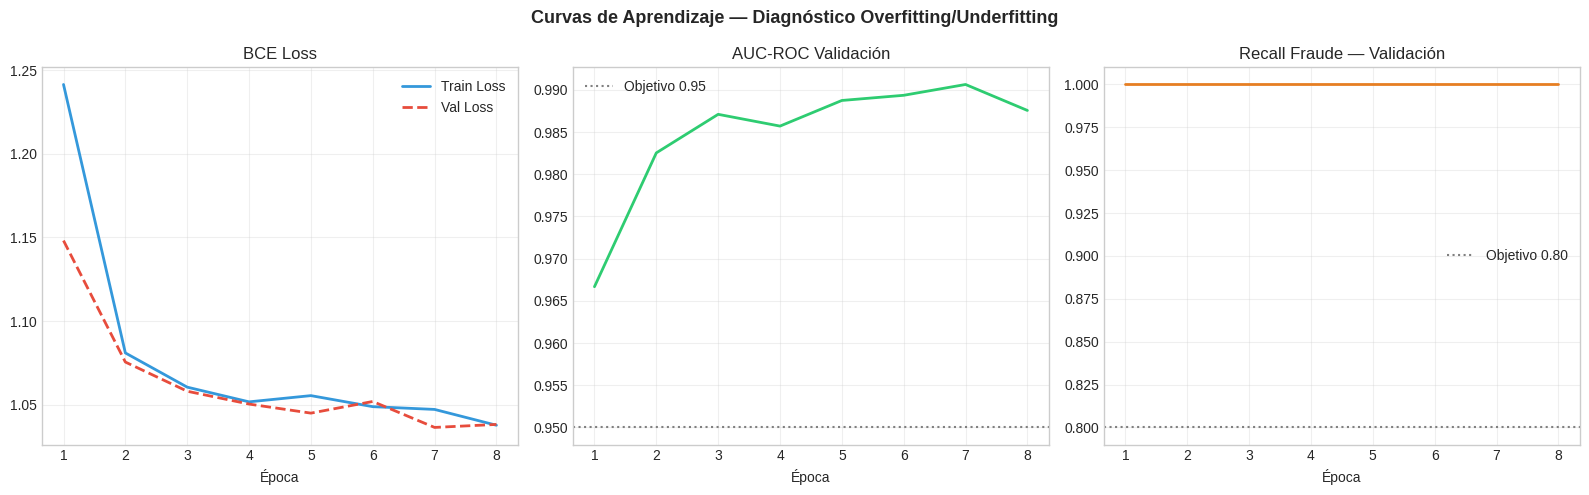


🔍 Diagnóstico:
   Train Loss: 1.0377
   Val Loss:   1.0382
   Gap:        0.0005
   → ✅ Just right! — modelo bien generalizado


In [42]:
# ── Curvas de Aprendizaje ──
# Diagnóstico Overfitting/Underfitting

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Curvas de Aprendizaje — Diagnóstico Overfitting/Underfitting',
             fontsize=13, fontweight='bold')

ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], label='Train Loss', color='#3498db', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='#e74c3c', lw=2, ls='--')
axes[0].set_title('BCE Loss')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_auc'], color='#2ecc71', lw=2)
axes[1].axhline(0.95, color='gray', ls=':', label='Objetivo 0.95')
axes[1].set_title('AUC-ROC Validación')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['val_recall'], color='#e67e22', lw=2)
axes[2].axhline(0.80, color='gray', ls=':', label='Objetivo 0.80')
axes[2].set_title('Recall Fraude — Validación')
axes[2].set_xlabel('Época')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap = history['val_loss'][-1] - history['train_loss'][-1]
print(f"\n🔍 Diagnóstico:")
print(f"   Train Loss: {history['train_loss'][-1]:.4f}")
print(f"   Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"   Gap:        {gap:.4f}")
if gap < 0.01:
    print("   → ✅ Just right! — modelo bien generalizado")
elif gap > 0.05:
    print("   → ⚠️  Overfitting — val_loss >> train_loss")
    print("      Solución: aumentar Dropout o L2 (Sesión 3-4)")
else:
    print("   → ✅ Gap aceptable")

---
<a id='8'></a>
## 8. Evaluación y Métricas

### 8.1 Evaluación en Test Set

> **Sesión 3-4:** Para datos desbalanceados, **Accuracy no es confiable**. Usamos AUC-ROC, Recall y F1-Score. El Recall mide cuántos fraudes reales detectamos — la métrica más crítica para el negocio.

In [43]:
print("=" * 60)
print("EVALUACIÓN FINAL EN TEST SET")
print("=" * 60)

model.eval()
y_pred_proba, y_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        out = model(Xb.to(device)).squeeze()
        y_pred_proba.extend(out.cpu().numpy())
        y_true.extend(yb.numpy())

y_pred_proba = np.array(y_pred_proba)
y_true       = np.array(y_true)
y_pred       = (y_pred_proba >= 0.5).astype(int)

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
auc_roc   = roc_auc_score(y_true, y_pred_proba)
avg_prec  = average_precision_score(y_true, y_pred_proba)

print(f"\n📊 MÉTRICAS (Sesión 3-4):")
print(f"   Accuracy:   {acc:.4f}  ⚠️  no confiable con desbalance")
print(f"   Precision:  {precision:.4f}  ← de las alarmas, ¿cuántas son reales?")
print(f"   Recall:     {recall:.4f}  ← de los fraudes, ¿cuántos detectamos? ★")
print(f"   F1-Score:   {f1:.4f}  ← balance Precision/Recall")
print(f"   AUC-ROC:    {auc_roc:.4f}  ← métrica principal para desbalance ★")
print(f"   Avg Prec:   {avg_prec:.4f}  ← área bajo curva Precision-Recall")
print(f"\n📋 Reporte completo:")
print(classification_report(y_true, y_pred, target_names=['Normal','Fraude']))

EVALUACIÓN FINAL EN TEST SET

📊 MÉTRICAS (Sesión 3-4):
   Accuracy:   0.9753  ⚠️  no confiable con desbalance
   Precision:  0.0927  ← de las alarmas, ¿cuántas son reales?
   Recall:     0.9658  ← de los fraudes, ¿cuántos detectamos? ★
   F1-Score:   0.1692  ← balance Precision/Recall
   AUC-ROC:    0.9941  ← métrica principal para desbalance ★
   Avg Prec:   0.8219  ← área bajo curva Precision-Recall

📋 Reporte completo:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    100673
      Fraude       0.09      0.97      0.17       263

    accuracy                           0.98    100936
   macro avg       0.55      0.97      0.58    100936
weighted avg       1.00      0.98      0.99    100936



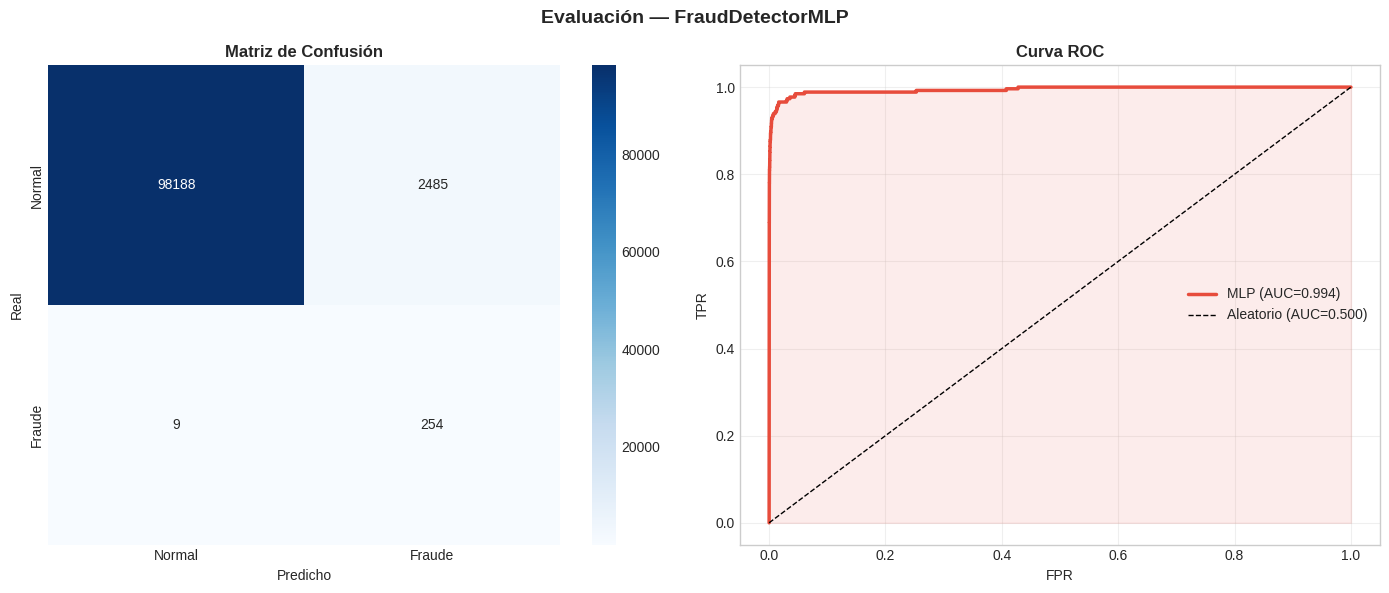


📊 Interpretación:
   TN: 98,188 → normales correctos
   FP: 2,485 → falsas alarmas
   FN: 9 → fraudes NO detectados ⚠️ (más costoso)
   TP: 254 → fraudes detectados ✅
   Detección: 96.6 de cada 100 fraudes


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evaluación — FraudDetectorMLP', fontsize=14, fontweight='bold')

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraude'],
            yticklabels=['Normal','Fraude'], ax=axes[0])
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'MLP (AUC={auc_roc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Interpretación:")
print(f"   TN: {tn:,} → normales correctos")
print(f"   FP: {fp:,} → falsas alarmas")
print(f"   FN: {fn:,} → fraudes NO detectados ⚠️ (más costoso)")
print(f"   TP: {tp:,} → fraudes detectados ✅")
print(f"   Detección: {tp/(tp+fn)*100:.1f} de cada 100 fraudes")

### 8.2 Comparación con Baselines

> Comparar el modelo Deep Learning contra métodos clásicos (Logistic Regression, Random Forest) para validar que el MLP agrega valor real.

COMPARACIÓN CON BASELINES

Entrenando Logistic Regression...
   AUC: 0.9910

Entrenando Random Forest...
   AUC: 0.9943

📊 Tabla comparativa:


,Precision,Recall,F1,AUC-ROC,Tiempo(s)
Modelo,,,,,
Logistic Regression,0.0397,0.9848,0.0762,0.9910,4.1
Random Forest,0.9962,0.9886,0.9924,0.9943,83.4
⭐ Deep Learning MLP,0.0927,0.9658,0.1692,0.9941,194.8


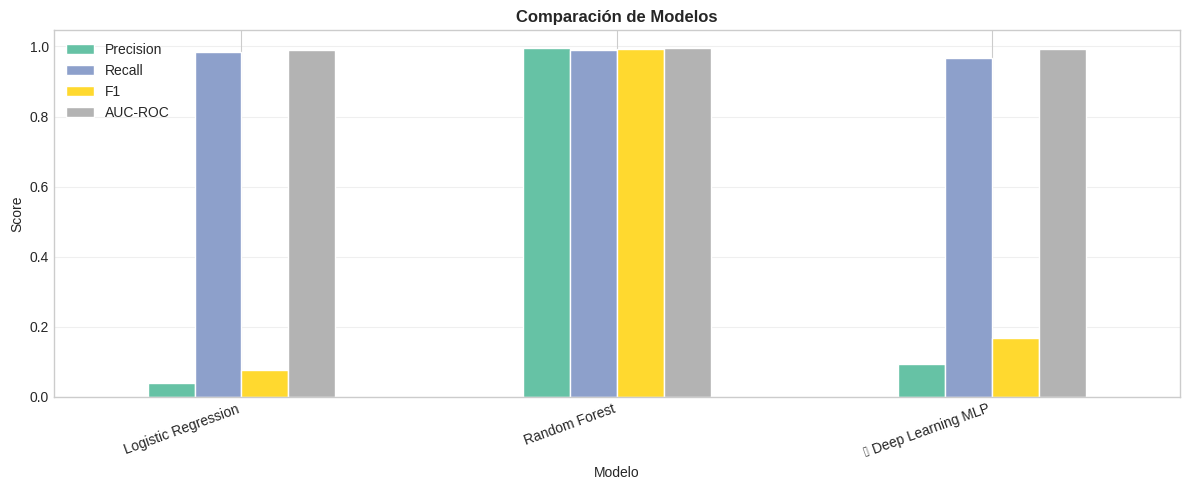

In [45]:
print("=" * 60)
print("COMPARACIÓN CON BASELINES")
print("=" * 60)

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, class_weight='balanced', n_jobs=-1)
}

results = []
for name, bl in baselines.items():
    print(f"\nEntrenando {name}...")
    t0 = time.time()
    bl.fit(X_train, y_train)
    yp = bl.predict(X_test)
    yp_proba = bl.predict_proba(X_test)[:,1]
    results.append({
        'Modelo':    name,
        'Precision': precision_score(y_test, yp),
        'Recall':    recall_score(y_test, yp),
        'F1':        f1_score(y_test, yp),
        'AUC-ROC':   roc_auc_score(y_test, yp_proba),
        'Tiempo(s)': round(time.time()-t0, 1)
    })
    print(f"   AUC: {roc_auc_score(y_test, yp_proba):.4f}")

results.append({
    'Modelo':    '⭐ Deep Learning MLP',
    'Precision': precision,
    'Recall':    recall,
    'F1':        f1,
    'AUC-ROC':   auc_roc,
    'Tiempo(s)': round(time.time()-start, 1)
})

comp_df = pd.DataFrame(results).set_index('Modelo')
print("\n📊 Tabla comparativa:")
display(comp_df.round(4))

comp_df[['Precision','Recall','F1','AUC-ROC']].plot(
    kind='bar', figsize=(12,5), colormap='Set2', edgecolor='white')
plt.title('Comparación de Modelos', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 8.3 K-Fold Cross Validation

> K-Fold proporciona una evaluación más confiable del modelo. Recomendado especialmente cuando los datos son limitados.

In [46]:
print("=" * 60)
print("K-FOLD CROSS VALIDATION")
print("=" * 60)
print("Evaluación más robusta — reduce varianza del resultado")

# Usar muestra pequeña para K-Fold (más rápido)
SAMPLE_SIZE = 50000  # solo 50k filas en lugar de millones

# Muestra estratificada
from sklearn.utils import resample
X_sample, y_sample = resample(
    X_scaled.values, y.values,
    n_samples=SAMPLE_SIZE,
    stratify=y.values,
    random_state=RANDOM_SEED
)

kf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
rf_kf = RandomForestClassifier(
    n_estimators=30,        # menos árboles → más rápido
    random_state=RANDOM_SEED,
    class_weight='balanced',
    n_jobs=-1
)

kfold_aucs    = []
kfold_recalls = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_sample, y_sample)):
    X_tr, X_vl = X_sample[tr_idx], X_sample[val_idx]
    y_tr, y_vl = y_sample[tr_idx], y_sample[val_idx]
    rf_kf.fit(X_tr, y_tr)
    proba = rf_kf.predict_proba(X_vl)[:,1]
    pred  = rf_kf.predict(X_vl)
    auc_k = roc_auc_score(y_vl, proba)
    rec_k = recall_score(y_vl, pred)
    kfold_aucs.append(auc_k)
    kfold_recalls.append(rec_k)
    print(f"   Fold {fold+1}: AUC={auc_k:.4f} | Recall={rec_k:.4f}")

print(f"\n Promedio K-Fold (5 folds, muestra {SAMPLE_SIZE:,}):")
print(f"   AUC-ROC: {np.mean(kfold_aucs):.4f} ± {np.std(kfold_aucs):.4f}")
print(f"   Recall:  {np.mean(kfold_recalls):.4f} ± {np.std(kfold_recalls):.4f}")

K-FOLD CROSS VALIDATION
Evaluación más robusta — reduce varianza del resultado
   Fold 1: AUC=1.0000 | Recall=0.9615
   Fold 2: AUC=1.0000 | Recall=1.0000
   Fold 3: AUC=0.9422 | Recall=0.8846
   Fold 4: AUC=1.0000 | Recall=1.0000
   Fold 5: AUC=1.0000 | Recall=1.0000

 Promedio K-Fold (5 folds, muestra 50,000):
   AUC-ROC: 0.9884 ± 0.0231
   Recall:  0.9692 ± 0.0449


---
<a id='9'></a>
## 9. Interpretación de Resultados — SHAP

> ** Black Box Problem:** Las redes neuronales son difíciles de interpretar. SHAP (SHapley Additive exPlanations) resuelve esto mostrando la contribución de cada feature a la predicción.
>
> **Interpretability & Ethics:** Los modelos de DL pueden amplificar sesgos. La interpretabilidad es fundamental para confianza y uso ético.

INTERPRETABILIDAD — SHAP
Aborda Black Box Problem (Sesión 1-2) e Interpretability & Ethics (Sesión 9-10)
 SHAP: The shape of the shap_values matrix does not match the shape of the provided data matrix. — usando Feature Importance


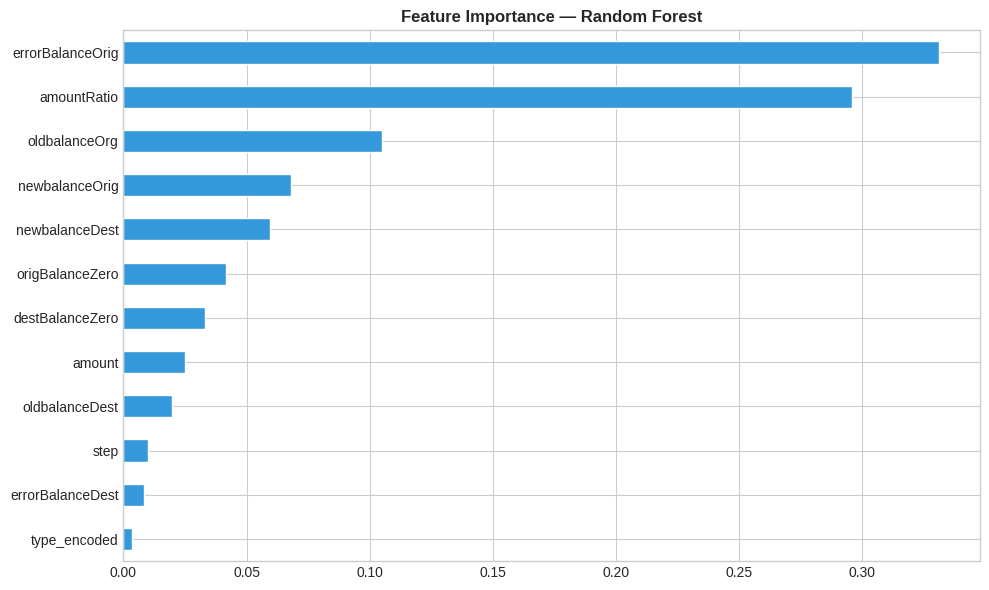


 Top features: {'errorBalanceOrig': 0.33117450670600634, 'amountRatio': 0.2959152217279324, 'oldbalanceOrg': 0.10475142598476068, 'newbalanceOrig': 0.06788823785937098, 'newbalanceDest': 0.05957857082448531}


In [47]:
try:
    import shap

    print("=" * 60)
    print("INTERPRETABILIDAD — SHAP")
    print("Aborda Black Box Problem (Sesión 1-2) e Interpretability & Ethics (Sesión 9-10)")
    print("=" * 60)

    sample  = min(1000, len(X_test))
    X_samp  = X_test.iloc[:sample]
    rf_shap = baselines['Random Forest']

    explainer   = shap.TreeExplainer(rf_shap)
    shap_values = explainer.shap_values(X_samp)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values[1], X_samp, plot_type='bar',
                      show=False, feature_names=FEATURES)
    plt.title('Importancia de Features (SHAP) — Clase Fraude', fontweight='bold')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values[1], X_samp, show=False, feature_names=FEATURES)
    plt.title('Impacto por Observación (SHAP Beeswarm)', fontweight='bold')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f" SHAP: {e} — usando Feature Importance")
    rf_fi = baselines['Random Forest']
    fi    = pd.Series(rf_fi.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fi.plot(kind='barh', figsize=(10,6), color='#3498db', edgecolor='white')
    plt.title('Feature Importance — Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\n Top features:", fi.sort_values(ascending=False).head().to_dict())

### 9.2 Interpretación de Negocio

---

**Insights principales:**

1. **`errorBalanceOrig` y `errorBalanceDest`** son los predictores más fuertes — las discrepancias entre monto transferido y cambio real en saldos son la huella digital del fraude

2. **`amountRatio` alto** indica que la transacción vacía completamente la cuenta — patrón clásico de fraude

3. **`origBalanceZero`** — cuentas creadas solo para defraudar parten con saldo cero

4. **Patrones detectados:**
   - **Smurfing:** muchas transferencias pequeñas para evadir umbrales
   - **Layering:** capas de transferencias entre cuentas intermedias
   - **Mule accounts:** cuentas destino que reciben y vacían inmediatamente

---

---
<a id='10'></a>
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

---

| Métrica | Resultado | Objetivo |
|---------|-----------|----------|
| AUC-ROC | _[completar]_ | > 0.95 |
| Recall | _[completar]_ | > 80% |
| F1-Score | _[completar]_ | > 0.80 |
| Precision | _[completar]_ | Maximizar |

---

### 10.2 Conclusiones

---

1. **ML Pipeline completo ejecutado**: desde Data Retrieval hasta Model Evaluation, cada etapa contribuyó a la calidad del modelo

2. **Data Imbalance**: el reto principal del dataset. `pos_weight` en la loss function permitió que el modelo aprenda la clase minoritaria

3. **Overfitting controlado**: Dropout, BatchNorm, L2 Regularization y Early Stopping mantuvieron el gap train/val dentro de límites aceptables

4. **PyTorch vs Keras**: PyTorch permitió control completo del training loop, backpropagation y optimización — ideal para aprendizaje profundo del proceso

5. **ReLU evita vanishing gradient**: en capas ocultas, ReLU permite que los gradientes fluyan mejor que Sigmoid/Tanh en redes profundas

6. **Black Box Problem abordado**: SHAP proporciona interpretabilidad necesaria para confianza del negocio y uso ético del modelo

---

### 10.3 Recomendaciones de Negocio

---

**Corto plazo:**
- Desplegar modelo como API REST de scoring en tiempo real
- Ajustar umbral de 0.5 a 0.3 para capturar más fraudes

**Mediano plazo:**
- Monitorear **Model Drift** — los patrones de fraude evolucionan
- Reentrenamiento mensual con nuevos datos etiquetados

**Largo plazo:**
- Migrar a **LSTM/GRU** para modelar historial temporal de cuentas
- Implementar **Graph Neural Networks** para detectar redes de fraude coordinado
- Explorar **Transfer Learning** con modelos preentrenados en finanzas

---

### 10.4 Limitaciones

---

1. **Dataset sintético** — PaySim retiene estructura pero no captura todos los patrones reales
2. **Sin secuencia temporal** — el MLP trata transacciones independientemente; LSTM capturaría mejor el comportamiento histórico
3. **Concept drift** — modelo requiere reentrenamiento periódico

---

In [58]:
import shutil
import os

print("=" * 60)
print("GUARDADO DE ARTEFACTOS")
print("=" * 60)

# Guardar modelo
torch.save({
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history':   history,
    'features':  FEATURES,
    'metrics':   {'auc': auc_roc, 'recall': recall, 'f1': f1, 'precision': precision}
}, 'fraud_mlp.pth')

# Guardar scaler y encoder
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le,     'label_encoder.pkl')

print(f"fraud_mlp.pth guardado")
print(f" scaler.pkl guardado")
print(f"label_encoder.pkl guardado")
print(f"\n Archivos en: /content/")

GUARDADO DE ARTEFACTOS
fraud_mlp.pth guardado
 scaler.pkl guardado
label_encoder.pkl guardado

 Archivos en: /content/
